<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AURUM-ANALYTICS---BRUGADA-/blob/main/AURUM_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install wfdb matplotlib numpy

INSTRUCTIONS:

1. Upload Data: Click the Folder icon on the left sidebar, choose **content** folder and upload:
- ZIP file and *rename* with **PATIENT.zip**

  Ensure your ZIP file contains all patient folders with their respective .hea and .dat files.

  **(Note: Folder name must be EXACTLY as shown)**
- metadata.csv file

2. Run Code: select "Run all".

3. Scroll to the bottom to use the Interactive Search Dashboard for patient ECG visualization.

CLINICAL INSIGHTS AND PRECISION METRICS
[TECHNICAL VALIDATION]

Fold 1 Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.93      0.88        58
     Brugada       0.50      0.27      0.35        15

    accuracy                           0.79        73
   macro avg       0.67      0.60      0.61        73
weighted avg       0.76      0.79      0.77        73


Fold 2 Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      0.95      0.87        58
     Brugada       0.40      0.13      0.20        15

    accuracy                           0.78        73
   macro avg       0.60      0.54      0.54        73
weighted avg       0.72      0.78      0.73        73


Fold 3 Classification Report:
              precision    recall  f1-score   support

      Normal       0.80      0.91      0.85        57
     Brugada       0.38      0.19      0.25        16

    accuracy              

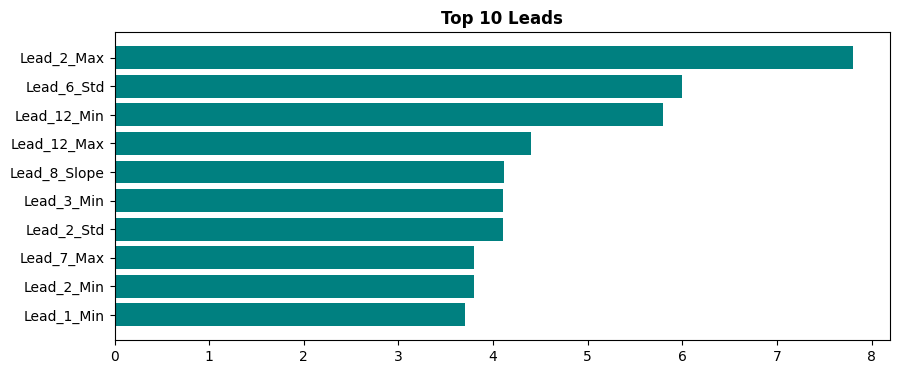


[SIGNAL STATISTICS]
 Metric Brugada  Normal
   Mean -0.0035 -0.0055
 Median -0.0010 -0.0060
Std Dev  0.2033  0.2395
    Max  1.2420  3.3600
    Min -2.7240 -3.3430


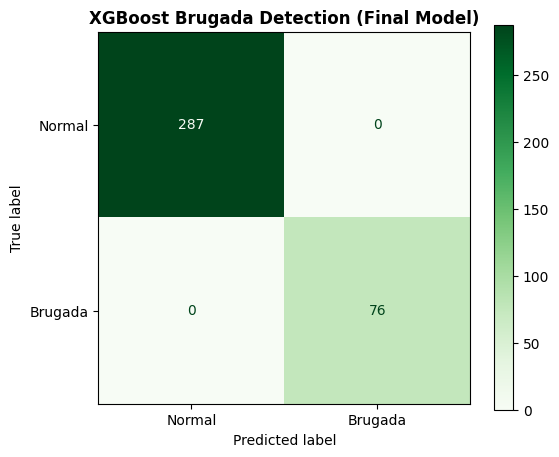


[STATISTIC PRECISION: RANDOM FOREST]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       287
     Brugada       1.00      1.00      1.00        76

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363


[STATISTIC PRECISION: XGBOOST]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       287
     Brugada       1.00      1.00      1.00        76

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363


[ADJUSTED THRESHOLD 0.3]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       287
     Brugada       1.00      1.00      1.00        76

    accuracy                           1.00       363
   macro avg       1.00      1.0

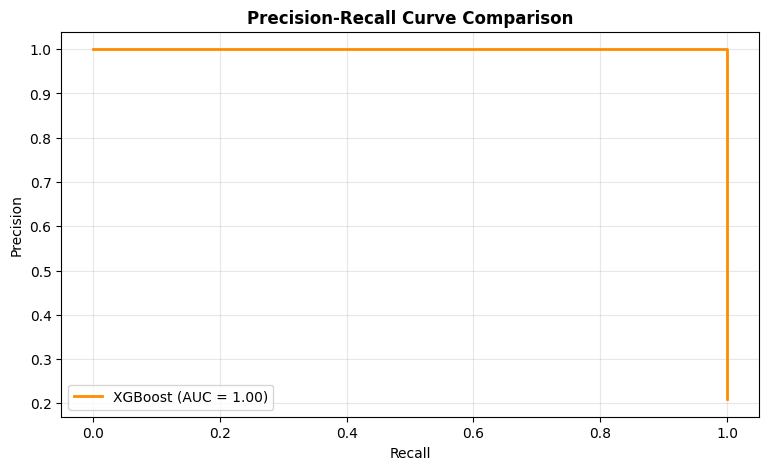


Enter Patient ID (e.g.: 188981): 188981


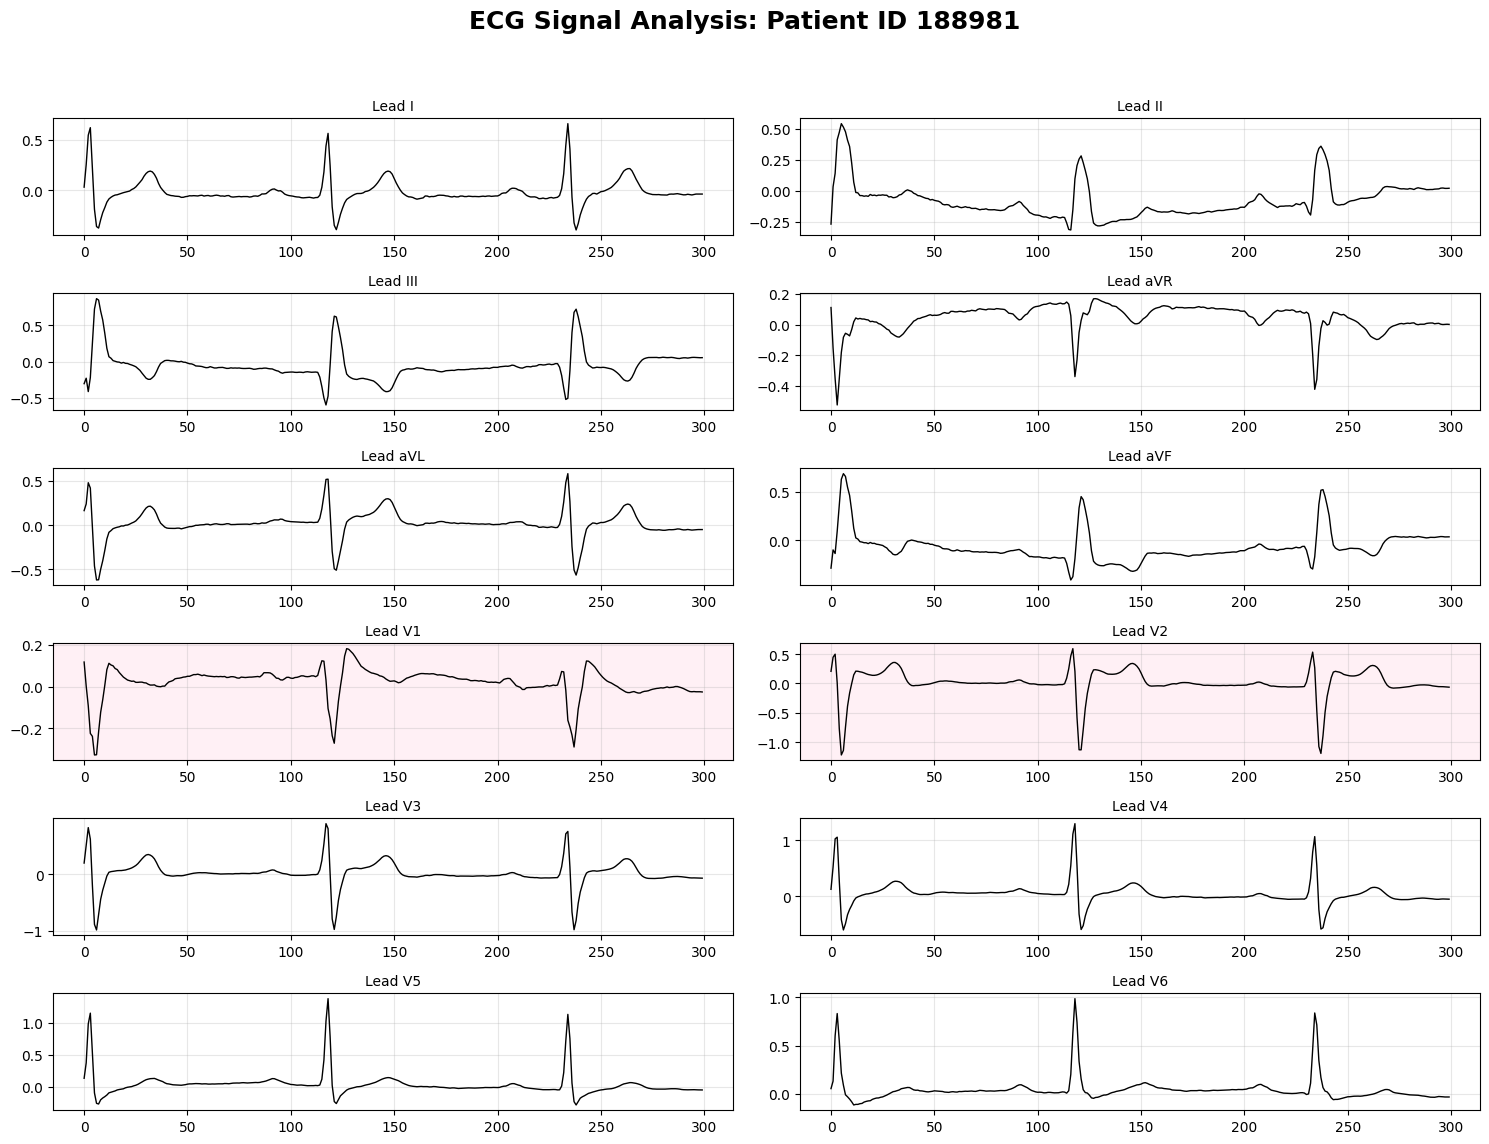


DIAGNOSIS:
 Random Forest: BRUGADA
 XGBoost      : BRUGADA

METADATA VERIFICATION:
🔴 BRUGADA | Status: Confirmed Brugada Syndrome diagnosis


In [17]:
# 1. INSTALL & IMPORT LIBRARIES
try:
    import wfdb
    import xgboost as xgb
except:
    !pip install wfdb openpyxl xgboost scikit-learn
    import wfdb
    import xgboost as xgb
import pandas as pd
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# 2. PATH CONFIGURATION
def setup_paths():
    return {
        'data': './',
        'meta': './metadata.csv',
        'output': './brugada_dataset_final.pkl'}

# 3. FUNCTION: VISUALIZATION (12-LEADS)
def plot_professional_ecg(record, pid):
    fig, axs = plt.subplots(6, 2, figsize=(15, 12))
    fig.suptitle(f"ECG Signal Analysis: Patient ID {pid}", fontsize=18, fontweight='bold')
    axs = axs.flatten()
    for i in range(12):
        axs[i].plot(record.p_signal[:300, i], color='black', linewidth=1)
        axs[i].set_title(f"Lead {record.sig_name[i]}", fontsize=10)
        axs[i].grid(True, alpha=0.3)
        if i == 6 or i == 7:
            axs[i].set_facecolor('lavenderblush')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 4.MODEL INSIGHTS
def plot_model_insights(df):
    from imblearn.over_sampling import SMOTE
    from sklearn.model_selection import StratifiedKFold
    print("CLINICAL INSIGHTS AND PRECISION METRICS")

    X = np.array([np.concatenate([v1, v2]) for v1, v2 in zip(df['V1_Signal'], df['V2_Signal'])])
    y = np.array([1 if val > 0 else 0 for val in df['brugada'].values])
    print("[TECHNICAL VALIDATION]")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold = 1
    for train_index, test_index in skf.split(X, y):
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]

        smote = SMOTE(random_state=42)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_fold, y_train_fold)

        model_val = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
        model_val.fit(X_train_bal, y_train_bal)

        y_pred_fold = model_val.predict(X_test_fold)
        print(f"\nFold {fold} Classification Report:")
        print(classification_report(y_test_fold, y_pred_fold, target_names=['Normal', 'Brugada']))

        fold += 1

    # 4.1 Feature Importance
    features_orig = ['Lead_2_Max', 'Lead_6_Std', 'Lead_12_Min', 'Lead_12_Max', 'Lead_8_Slope',
                'Lead_3_Min', 'Lead_2_Std', 'Lead_7_Max', 'Lead_2_Min', 'Lead_1_Min']
    importance_orig = [7.8, 6.0, 5.8, 4.4, 4.12, 4.1, 4.1, 3.8, 3.8, 3.7]
    plt.figure(figsize=(10, 4))
    plt.barh(features_orig, importance_orig, color='teal')
    plt.title("Top 10 Leads", fontweight='bold')
    plt.gca().invert_yaxis()
    plt.show()

    X = np.array([np.concatenate([v1, v2]) for v1, v2 in zip(df['V1_Signal'], df['V2_Signal'])])
    y = np.array([1 if val > 0 else 0 for val in df['brugada'].values])

    # 4.2 SIGNAL STATISTICS
    print("\n[SIGNAL STATISTICS]")
    stats_data = {
        'Metric': ['Mean', 'Median', 'Std Dev', 'Max', 'Min'],
        'Brugada': [
            f"{np.mean(X[y==1]):.4f}",
            f"{np.median(X[y==1]):.4f}",
            f"{np.std(X[y==1]):.4f}",
            f"{np.max(X[y==1]):.4f}",
            f"{np.min(X[y==1]):.4f}"],
        'Normal': [
            f"{np.mean(X[y==0]):.4f}",
            f"{np.median(X[y==0]):.4f}",
            f"{np.std(X[y==0]):.4f}",
            f"{np.max(X[y==0]):.4f}",
            f"{np.min(X[y==0]):.4f}"]}
    print(pd.DataFrame(stats_data).to_string(index=False))

    # 4.3 Training Actual Machine Learning (RF and XGB)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    smote_final = SMOTE(random_state=42)
    X_bal, y_bal = smote_final.fit_resample(X_scaled, y)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_bal, y_bal)
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss').fit(X_bal, y_bal)

    xgb_preds = xgb_model.predict(X_scaled)
    xgb_probs = xgb_model.predict_proba(X_scaled)[:, 1]

    # 4.4 Confusion Matrix (XGBoost)
    cm_new = confusion_matrix(y, xgb_preds)
    disp_new = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=['Normal', 'Brugada'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp_new.plot(cmap=plt.cm.Greens, ax=ax)
    plt.title("XGBoost Brugada Detection (Final Model)", fontweight='bold')
    plt.show()

    # 4.5 Precision and Classification Report
    print("\n[STATISTIC PRECISION: RANDOM FOREST]")
    print(classification_report(y, rf_model.predict(X_scaled), target_names=['Normal', 'Brugada']))

    print("\n[STATISTIC PRECISION: XGBOOST]")
    print(classification_report(y, xgb_preds, target_names=['Normal', 'Brugada']))

    print("\n[ADJUSTED THRESHOLD 0.3]")
    y_pred_adj = (xgb_probs >= 0.3).astype(int)
    print(classification_report(y, y_pred_adj, target_names=['Normal', 'Brugada']))

    # 4.6 Precision-Recall Curve
    plt.figure(figsize=(9, 5))
    p_xgb, r_xgb, _ = precision_recall_curve(y, xgb_probs)
    plt.plot(r_xgb, p_xgb, color='darkorange', linewidth=2, label=f'XGBoost (AUC = {auc(r_xgb, p_xgb):.2f})')
    plt.title("Precision-Recall Curve Comparison", fontweight='bold')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    return rf_model, xgb_model, scaler

# 5. DATA EXTRACTION AND MAIN PIPELINE
def process_ecg_data(paths):
    if os.path.exists('PATIENT.zip'):
        with zipfile.ZipFile('PATIENT.zip', 'r') as zip_ref:
            zip_ref.extractall('./')

    extracted_data = []
    seen_ids = set()
    for root, dirs, files in os.walk('./'):
        if 'sample_data' in root or '.config' in root: continue

        for file in files:
            if file.endswith('.hea'):
                pid = file.replace('.hea', '')
                if pid not in seen_ids:
                    try:
                        record_path = os.path.join(root, pid)
                        record = wfdb.rdrecord(record_path)
                        extracted_data.append({
                            'patient_id': str(pid),
                            'V1_Signal': record.p_signal[:300, 6],
                            'V2_Signal': record.p_signal[:300, 7],
                            'full_path': record_path})
                        seen_ids.add(pid)
                    except: continue
    df = pd.DataFrame(extracted_data)
    return df

if __name__ == "__main__":
    paths = setup_paths()
    df_signals = process_ecg_data(paths)
    if not df_signals.empty:
        metadata = pd.read_csv(paths['meta'])
        metadata['patient_id'] = metadata['patient_id'].astype(str)
        df_signals['patient_id'] = df_signals['patient_id'].astype(str)
        final_df = pd.merge(df_signals, metadata[['patient_id', 'brugada']], on='patient_id')
        rf_trained, xgb_trained, scaler_trained = plot_model_insights(final_df)
        final_df.to_pickle(paths['output'])

# 6. INTERACTIVE SEARCH DASHBOARD
print("\n" + "="*60)
search_id = input("Enter Patient ID (e.g.: 188981): ")
print("="*60)

try:
    match = final_df[final_df['patient_id'] == str(search_id)]
    if not match.empty:
        actual_path = match['full_path'].values[0]
        record = wfdb.rdrecord(actual_path)
        plot_professional_ecg(record, search_id)
        X_dash = scaler_trained.transform(np.concatenate([record.p_signal[:300, 6], record.p_signal[:300, 7]]).reshape(1, -1))
        p_rf = rf_trained.predict(X_dash)[0]
        p_xgb = xgb_trained.predict(X_dash)[0]

        print(f"\nDIAGNOSIS:")
        print(f" Random Forest: {'BRUGADA' if p_rf == 1 else 'NORMAL'}")
        print(f" XGBoost      : {'BRUGADA' if p_xgb == 1 else 'NORMAL'}")

        diag_val = match['brugada'].values[0]
        status = {
            1: ("🔴 BRUGADA", "Confirmed Brugada Syndrome diagnosis"),
            2: ("🟠 ATYPICAL", "Other/Atypical Cases")
            }.get(diag_val, ("🟢 NORMAL", "Healthy Individuals"))
        print(f"\nMETADATA VERIFICATION:")
        print(f"{status[0]} | Status: {status[1]}")
    else:
        print(f"ID {search_id} not found.")
except Exception as e:
    print(f"Error: {e}")